# Calcium Aluminosilicate Glass Simulation with Pedone Potential

Simulation using the parameters from Pedone JPCB 2006 (DSF is used for Coulomb as well).
Used a small sample with a 200 molecules; the number of steps is reduced a lot for testing purposes and not to be used in a real simulation. 

The number of atoms and box size are calculated automatically from the composition and density.

# === Simulation Capabilities ===

Supported Elements from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

### Typical Compositions:
### ------------

- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems

### Available Modifier Cations:
### ------------
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

### Standard Simulation Parameters:
### ------------
- The cooling is performed in NVT and the stress is relaxed at 300 K in NPT. 
- Cooling rate: 1 K/ps typical, customizable, lower is better but more time consuming.
- Temperature range: The cooling is performed between $T$ = 5000 K and $T$ = 300 K. this is sujective to change depending on the composition. Usually lower heating temperature are acceptable when large percentage of modifiers is present in the sample.
- Ensemble: NVT or NPT (LAMMPS-based control), Langevin can be used by adding keywork langevin = True in the meltquench function.
- Time step: 1 - 2 fs are typical.

### Tooling:
### ------------
- Structure generation from composition string
- Automatic charge and potential parameter assignment
- Periodic boundary conditions are enforced
- LAMMPS data file output (atom_style charge)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project

In [11]:
from pyiron_glass import (
    melt_quench_simulation,
    potential,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [12]:
def print_help():
    print("=== Simulation Capabilities ===\n")
    
    print("Supported Elements (# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018:\n")
    print(", ".join(sorted(potential.pedone_potential_params.keys())))
    
    print("\nTypical Compositions:")
    print("- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.")
    print("- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)")
    print("- Mixed network formers: SiO2-P2O5-Al2O3 systems")
    
    print("\nAvailable Modifier Cations:")
    print("- Alkali: Li, Na, K")
    print("- Alkaline Earth: Be, Mg, Ca, Sr, Ba")
    print("- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.")
    
    print("\nStandard Simulation Parameters:")
    print("- Cooling rate: 1 K/ps typical, customizable, lower is better but more time consuming.")
    print("- Temperature range: up to ~5000 K is acceptable and sujective to change depending on the composition")
    print("- Ensemble: NVT or NPT (LAMMPS-based control), Langevin can be used by adding keywork langevin = True in the meltquench function")
    print("- Time step: 1 - 2 fs are typical")
    
    print("\nTooling:")
    print("- Structure generation from composition string")
    print("- Automatic charge and potential parameter assignment")
    print("- Periodic boundary conditions are enforced")
    print("- LAMMPS data file output (atom_style charge)")


In [13]:
print_help()

=== Simulation Capabilities ===

Supported Elements (# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

Typical Compositions:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems

Available Modifier Cations:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Standard Simulation Parameters:
- Cooling rate: 1 K/ps typical, customizable, lower is better but more time consuming.
- Temperature range: up to ~5000 K is acceptable and sujective to change depending on the composition
- Ensemble: NVT or NPT (LAMMPS-based control), Langevin can be used by adding keywork langevin = True in the meltquench function
- Time step: 1 - 2 fs are typical

Tooling:
- Structure generation from composition s

In [22]:
"""
Author: Achraf Atila (achraf.atila@bam.de)

Description:
------------
This script provides a collection of analysis functions for multicomponent glass structures based on LAMMPS dump files.
It supports structural characterization using atomic-level information and includes the following features:

Available Analyses:
-------------------
- Coordination Numbers: Computes how many neighbors each atom has within a cutoff.
- Bridging and Non-Bridging Oxygens: Determines network connectivity through oxygen coordination.
- Qn Distribution: Counts the number of bridging oxygens attached to each former (e.g., Si), yielding Qⁿ statistics.
- Bond Angle Distribution: Calculates the angles between triplets of atoms to assess structural order.
- Network Connectivity: Computes average Qⁿ value across the system.
- Filtering: Allows exclusion of specific atom types from the system.
- Periodic Boundary Conditions (PBC): All neighbor searches account for PBC using a cell list algorithm.

Input:
------
- LAMMPS dump file (optionally gzipped).
  Required fields: atom ID, type, coordinates (wrapped or unwrapped), and box dimensions.

Main Functions:
---------------
- `read_lammps_dump()`: Read atom data and box size.
- `remove_atom_type()`: Remove unwanted atom types.
- `compute_cell_list()`, `get_neighbors()`: Accelerated neighbor search using a cell list.
- `compute_coordination()`: Coordination histogram for a given atom type.
- `compute_Qn()`: Compute Qⁿ and partial Qⁿ distributions.
- `compute_network_connectivity()`: Calculate the average Qⁿ.
- `compute_angles()`: Compute bond angle distributions (partial implementation).
- `write_distribution_to_file()`: Output histogram data to file.

Note:
-----
This script assumes that atoms are distributed in a cubic or orthorhombic box under PBC.
Future features will extend to medium-range order, ring statistics, and cluster size distributions.
"""


'\nAuthor: Achraf Atila (achraf.atila@bam.de)\n\nDescription:\n------------\nThis script provides a collection of analysis functions for multicomponent glass structures based on LAMMPS dump files.\nIt supports structural characterization using atomic-level information and includes the following features:\n\nAvailable Analyses:\n-------------------\n- Coordination Numbers: Computes how many neighbors each atom has within a cutoff.\n- Bridging and Non-Bridging Oxygens: Determines network connectivity through oxygen coordination.\n- Qn Distribution: Counts the number of bridging oxygens attached to each former (e.g., Si), yielding Qⁿ statistics.\n- Bond Angle Distribution: Calculates the angles between triplets of atoms to assess structural order.\n- Network Connectivity: Computes average Qⁿ value across the system.\n- Filtering: Allows exclusion of specific atom types from the system.\n- Periodic Boundary Conditions (PBC): All neighbor searches account for PBC using a cell list algorithm

In [14]:
pr = Project("test")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=200, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)

In [15]:
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    langevin=False,
    pyiron_project=pr,
)

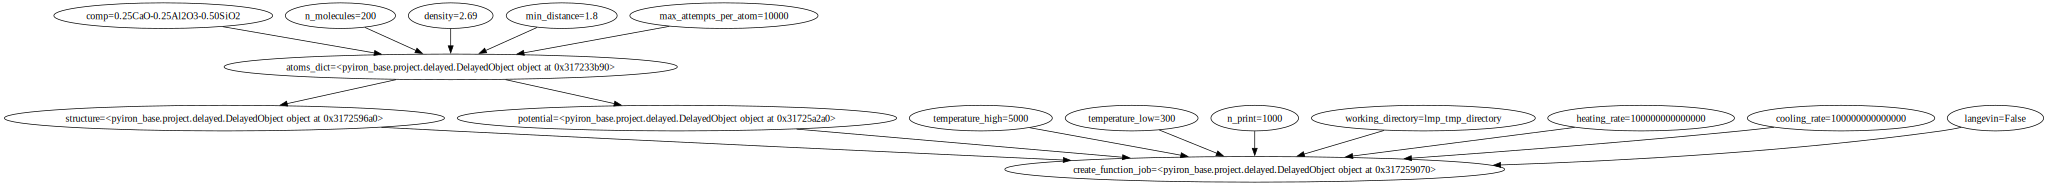

In [16]:
delayed.draw()

In [17]:
result = delayed.pull() 

The job get_ase_structure_32e0198a0681ed25ebf6ad2d92751f1b was saved and received the ID: 604
The job generate_potential_c34990616df3359fc6761eb844449c06 was saved and received the ID: 605


/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


In [18]:
mean_temp = np.mean(result["temperature"])
print(f"{mean_temp:.1f} K")


299.9 K


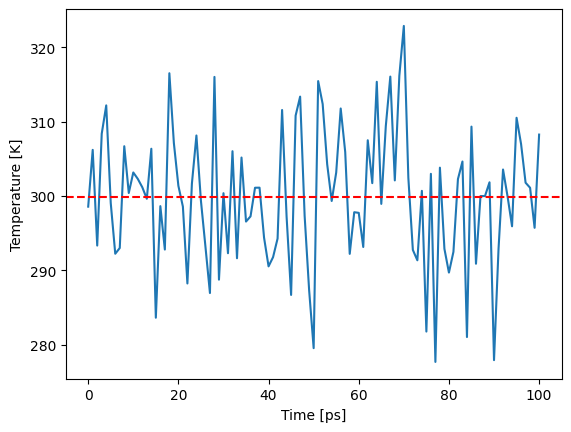

In [19]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [20]:
print(result["structure"])

Atoms(symbols='Al100Ca50O400Si100', pbc=True, cell=[[20.21081281477462, 3.712666083267007e-15, 3.712666083267008e-15], [-2.4751107220831414e-15, 20.210812814, 3.7126660831247115e-15], [-2.475110722083141e-15, -2.4751107220831414e-15, 20.210812814]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


In [21]:
"# NBVAL_CHECK_OUTPUT"

from ase import units

V = np.mean(result["generic"]["volume"])*1e-24 # volume in cm#
massTot = result["structure"].get_masses().sum()/units._Nav

density = massTot/V
print(f"{(massTot/V):.2f} g/cm3") 

2.80 g/cm3
